In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
%matplotlib inline
from scipy.optimize import curve_fit
from scipy.optimize import differential_evolution
from scipy.special import kv
import glob
import os
import datetime

In [2]:
folder_path = './FC77_5um_2st_3.899mm' 
file_paths = glob.glob(os.path.join(folder_path, '*.txt'))
data_dict = {}
file_names = {}
press_map = {}
temp_map = {}
cur_map = {}
match_length = re.search(r'([\d\.]+)mm', folder_path)
wire_length = float(match_length.group(1)) if match_length else None
match_diameter = re.search(r'([\d\.]+)um', folder_path)
wire_diameter = float(match_diameter.group(1)) if match_diameter else None
columns = [' Current_Freq(Hz)', ' Heater_Freq(Hz)', 'Vomega(V)', ' ImVomega(V)', 'V3omega(V)', ' ImV3omega(V)']
print("=== 読み込み開始 ===")

for i, filepath in enumerate(file_paths, start=1):
    filename = os.path.basename(filepath)
    key = f'df_{i}'
    match_press = re.search(r'([\d\.]+)Gpa', filename)
    match_temp = re.search(r'(\d+)K', filename)
    match_cur = re.search(r'(\d+)mA', filename)
    press = float(match_press.group(1)) if match_press else None
    temp = int(match_temp.group(1)) if match_temp else None
    cur = int(match_cur.group(1)) if match_cur else None
    file_names[key] = filename
    if press is not None: press_map[key] = press
    if temp is not None: temp_map[key] = temp
    if cur is not None: cur_map[key] = cur
    skip_idx = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            if line.startswith('Columns>>'):
                skip_idx = idx + 1 
                break 
                
    df = pd.read_csv(filepath, sep=r'\s+', skiprows=skip_idx, names=columns)
    globals()[key] = df
    print(f"{key:6} : {filename:20} 圧力: {press}Gpa  温度: {temp}K  電流: {cur}mA")

print("\n=== 全ファイルの読み込み完了 ===")

=== 読み込み開始 ===
df_1   : 0.0Gpa_150K_10mA.txt 圧力: 0.0Gpa  温度: 150K  電流: 10mA
df_2   : 0.0Gpa_160K_10mA.txt 圧力: 0.0Gpa  温度: 160K  電流: 10mA
df_3   : 0.0Gpa_170K_10mA.txt 圧力: 0.0Gpa  温度: 170K  電流: 10mA
df_4   : 0.0Gpa_180K_10mA.txt 圧力: 0.0Gpa  温度: 180K  電流: 10mA
df_5   : 0.0Gpa_190K_10mA.txt 圧力: 0.0Gpa  温度: 190K  電流: 10mA
df_6   : 0.0Gpa_200K_10mA.txt 圧力: 0.0Gpa  温度: 200K  電流: 10mA
df_7   : 0.0Gpa_220K_10mA.txt 圧力: 0.0Gpa  温度: 220K  電流: 10mA
df_8   : 0.0Gpa_230K_10mA.txt 圧力: 0.0Gpa  温度: 230K  電流: 10mA
df_9   : 0.0Gpa_240K_10mA.txt 圧力: 0.0Gpa  温度: 240K  電流: 10mA
df_10  : 0.0Gpa_250K_10mA.txt 圧力: 0.0Gpa  温度: 250K  電流: 10mA
df_11  : 0.0Gpa_300K_10mA.txt 圧力: 0.0Gpa  温度: 300K  電流: 10mA
df_12  : 0.0Gpa_4_210K_10mA.txt 圧力: 0.0Gpa  温度: 210K  電流: 10mA

=== 全ファイルの読み込み完了 ===


df_1 の平均抵抗値: 9.2625256410
df_2 の平均抵抗値: 9.9496600733
df_3 の平均抵抗値: 10.4896835365
df_4 の平均抵抗値: 11.4673329478
df_5 の平均抵抗値: 12.0947216783
df_6 の平均抵抗値: 13.0321993179
df_7 の平均抵抗値: 15.1070351648
df_8 の平均抵抗値: 16.0364417582
df_9 の平均抵抗値: 16.6577128205
df_10 の平均抵抗値: 17.4782761905
df_11 の平均抵抗値: 22.0605750916
df_12 の平均抵抗値: 14.2940498168


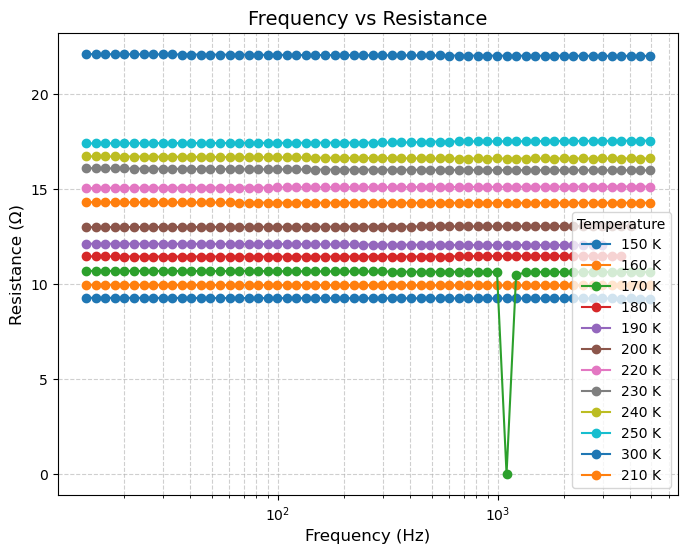

In [3]:
freq_min = 13.0
freq_max = 10000.0
 #電圧の周波数範囲
first_number=1
last_number=12
 #データの用いる数
average_res = {}
average_Vw = {}

for i in range(first_number, last_number+1):
    df_name = f'df_{i}'
    current_df = globals().get(df_name)
    if current_df is None:
        print(f"データフレーム '{df_name}' が見つかりませんでした。スキップします。")
        continue
    try:
        current_df['resistance'] = np.abs(current_df['Vomega(V)'])/(cur_map[df_name]*10**-3)
        filtered_df = current_df[(current_df[' Current_Freq(Hz)'] >= freq_min) & (current_df[' Current_Freq(Hz)'] <= freq_max)]
        avg_Vw = np.abs(filtered_df['Vomega(V)']).mean()
        average_Vw[df_name] = avg_Vw
        avg_res = filtered_df['resistance'].mean()
        average_res[df_name] = avg_res
        print(f"{df_name} の平均抵抗値: {avg_res:.10f}")
    except KeyError as e:
        print(f"エラー: {df_name} に列 {e} がありません。")
    except Exception as e:
        print(f"エラー: {df_name} で予期せぬエラーが発生しました: {e}")
        import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
for i in range(first_number, last_number+1):
    df_name = f'df_{i}'
    current_df = globals().get(df_name)   
    if current_df is None:
        continue
    try:
        filtered_df = current_df[(current_df[' Current_Freq(Hz)'] >= freq_min) & (current_df[' Current_Freq(Hz)'] <= freq_max)]
        temperature = temp_map.get(df_name, 'Unknown')
        plot_label = f"{temperature} K" 
        plt.plot(filtered_df[' Current_Freq(Hz)'], filtered_df['resistance'], marker='o', linestyle='-', label=plot_label) 
    except KeyError as e:
        print(f"グラフ描画エラー: {df_name} に列がありません。")
        continue
now_str = datetime.datetime.now().strftime('%Y_%m%d_%H;%M;%S')        
plt.xscale('log')  
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Resistance (Ω)', fontsize=12)
plt.title('Frequency vs Resistance', fontsize=14)
plt.legend(title='Temperature')
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.savefig(f'解析画像/抵抗の温度依存性(圧力媒体)/周波数依存性(金属線の抵抗)_{now_str}.svg', format='svg', bbox_inches='tight')
plt.show()

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

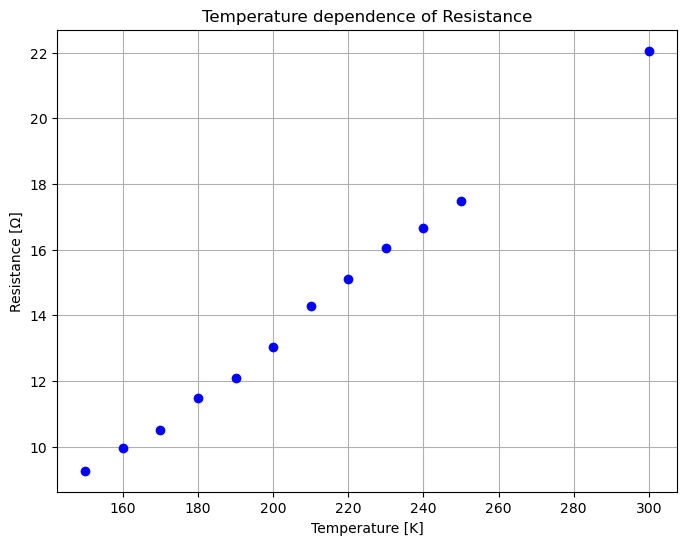

In [4]:
x_temps = []
y_res = []
for key, temp in temp_map.items():
    if key in average_res:
        x_temps.append(temp)           
        y_res.append(average_res[key])  
        plt.figure(figsize=(8, 6))         
plt.plot(x_temps, y_res, marker='o',  linestyle='None',color='blue') 
plt.xlabel('Temperature [K]') 
plt.ylabel('Resistance [Ω]')  
plt.title('Temperature dependence of Resistance') 
plt.grid(True) 

a (傾き)  : 0.08663 +/- 0.00144
b (切片)  : -4.05270 +/- 0.30535
フィッティング式: y = 0.08663x + -4.05270


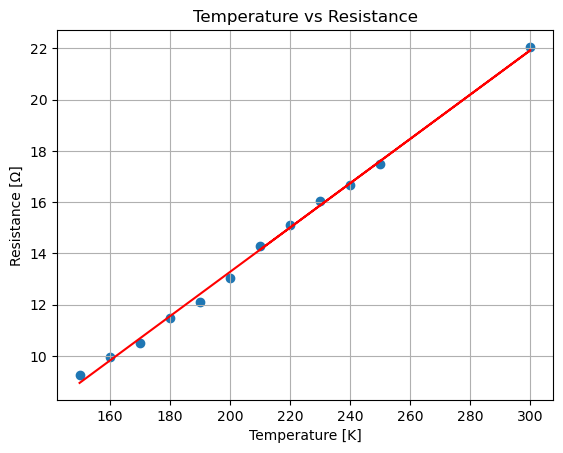

In [5]:
def model(x,a,b):
    return x*a+b
param,cover=curve_fit(model,x_temps,y_res)
a = param[0]
b = param[1]
y_fit=model(np.array(x_temps),param[0],param[1])
perr = np.sqrt(np.diag(cover))
a_err = perr[0] 
b_err = perr[1] 
plt.scatter(np.array(x_temps),y_res)
plt.plot(x_temps,y_fit,color='red')
plt.xlabel('Temperature [K]')  
plt.ylabel('Resistance [Ω]')  
plt.title('Temperature vs Resistance') 
plt.grid(True)
now_str = datetime.datetime.now().strftime('%Y_%m%d_%H;%M;%S')
plt.savefig(f'解析画像/抵抗の温度依存性(圧力媒体)/金属膜の抵抗_{now_str}.svg', format='svg', bbox_inches='tight')

print(f"a (傾き)  : {a:.5f} +/- {a_err:.5f}")
print(f"b (切片)  : {b:.5f} +/- {b_err:.5f}")
print(f"フィッティング式: y = {a:.5f}x + {b:.5f}")

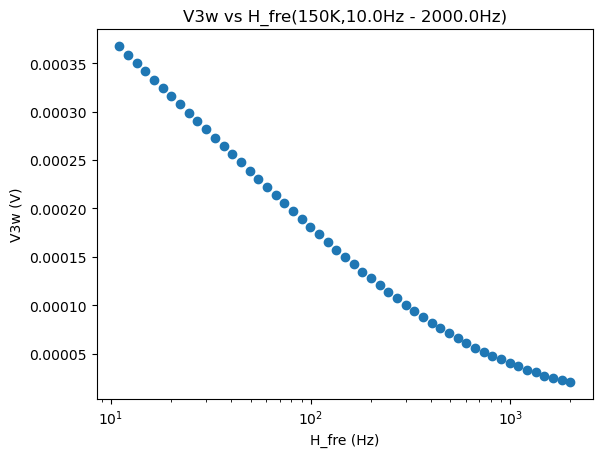

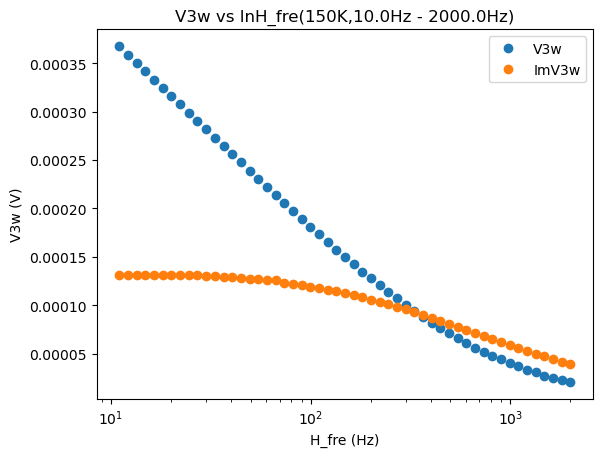

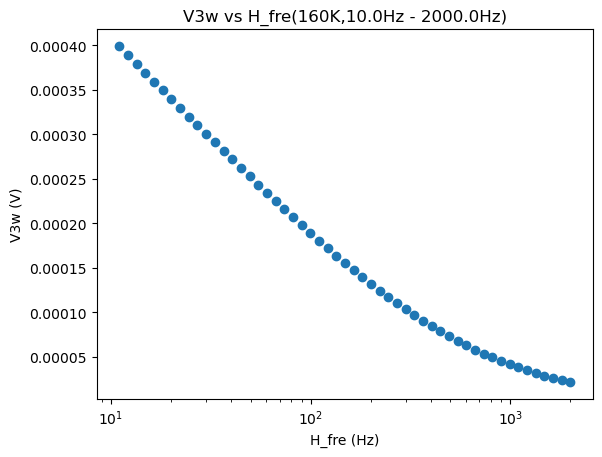

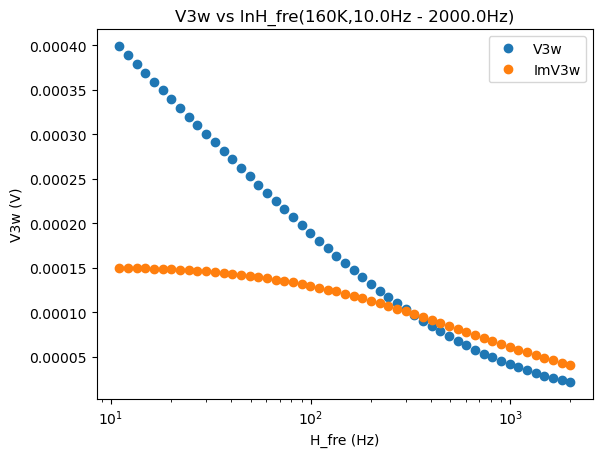

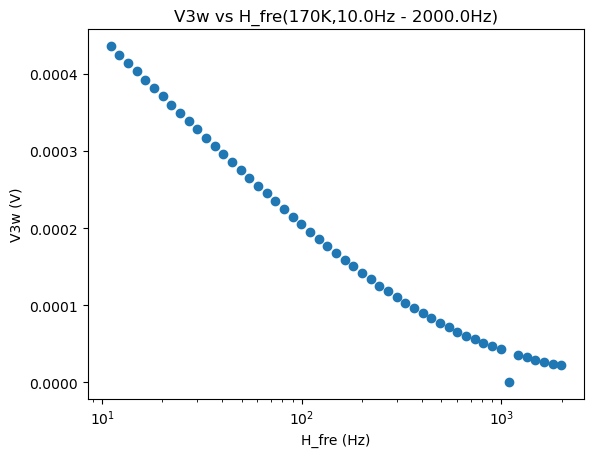

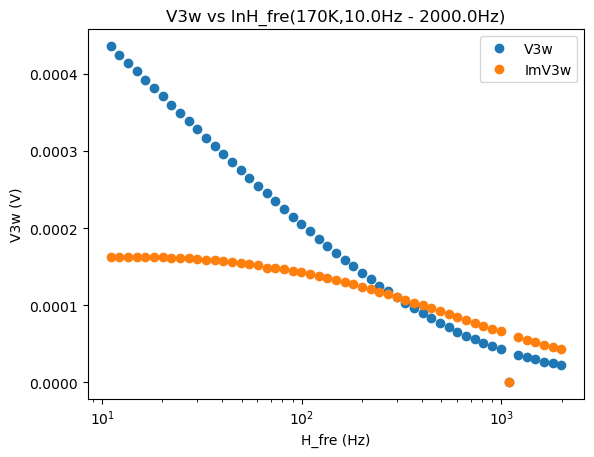

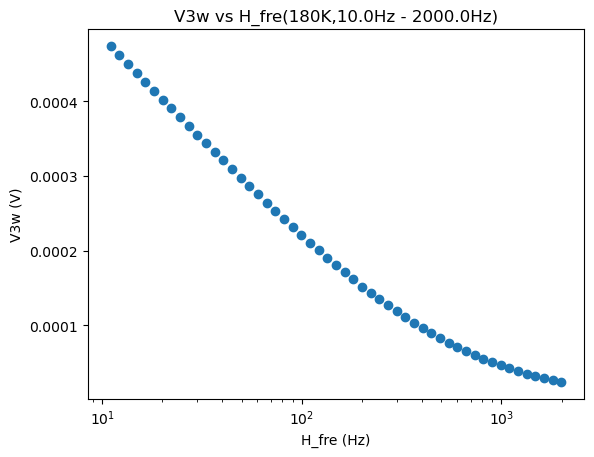

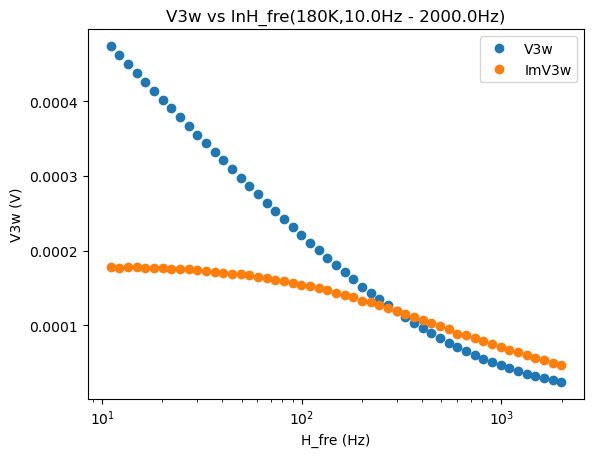

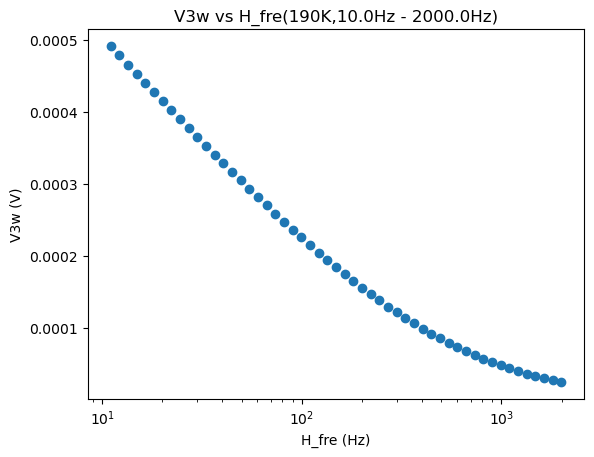

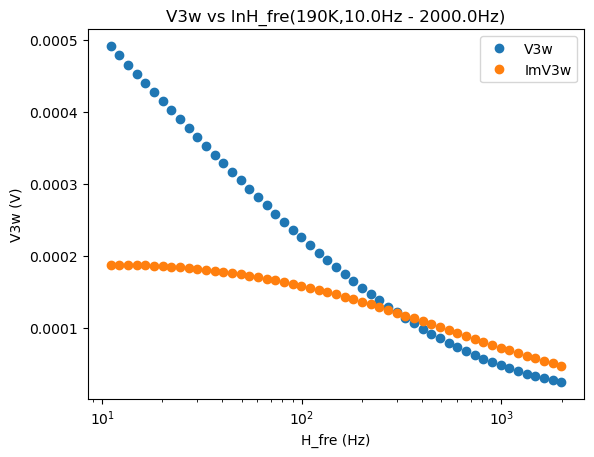

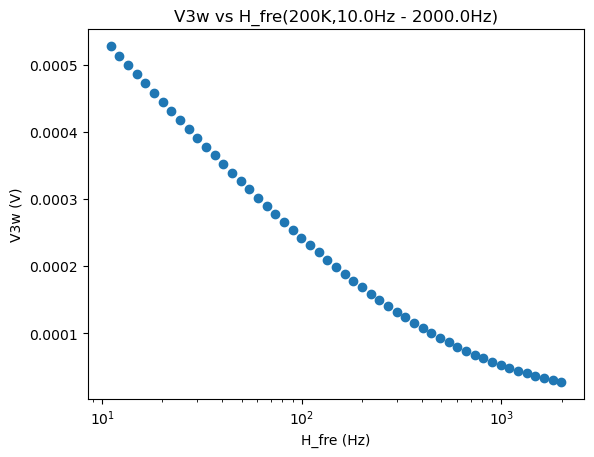

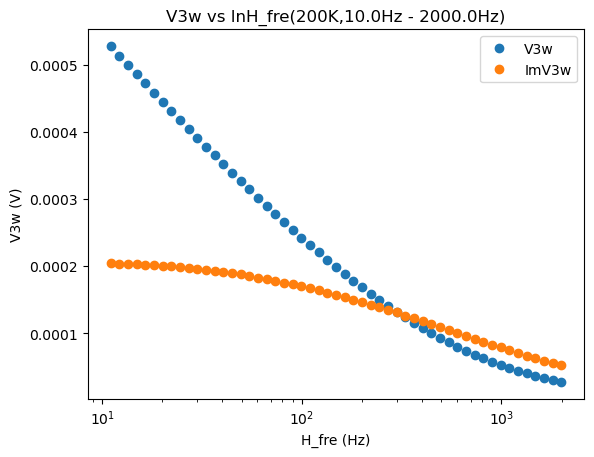

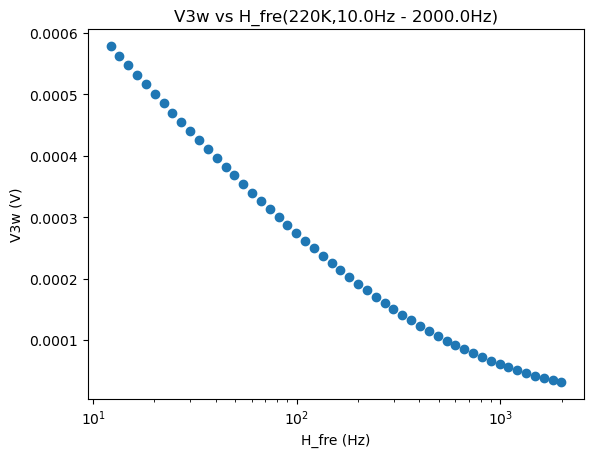

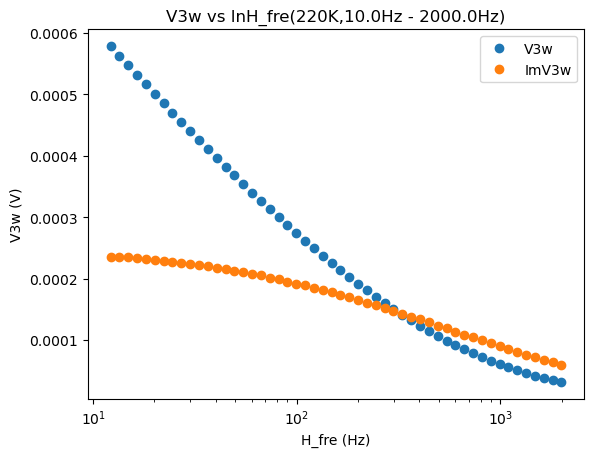

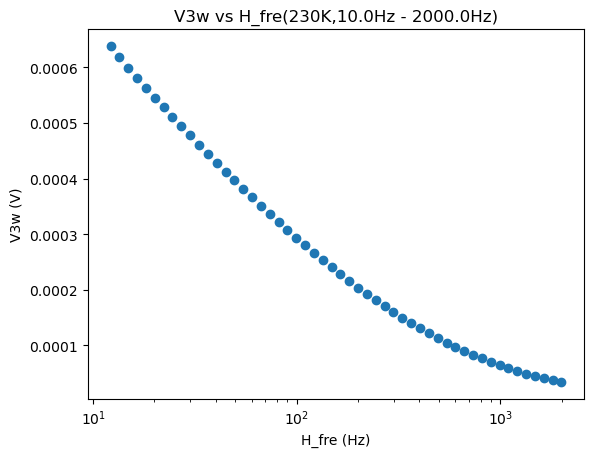

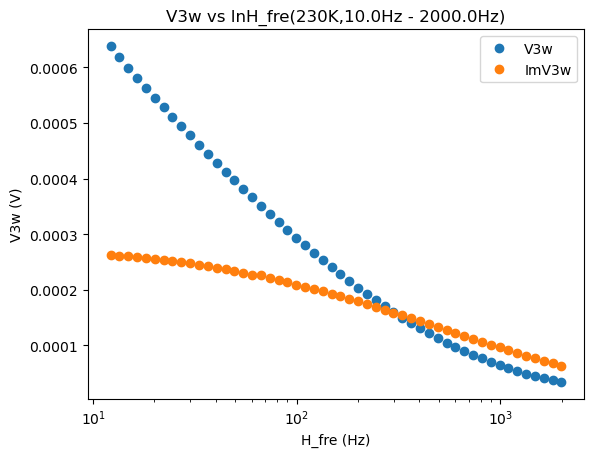

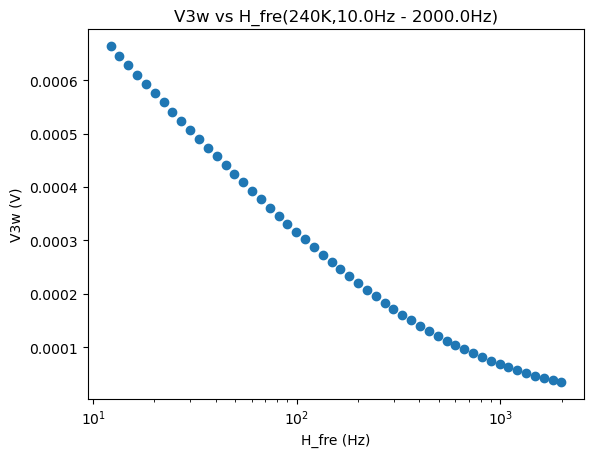

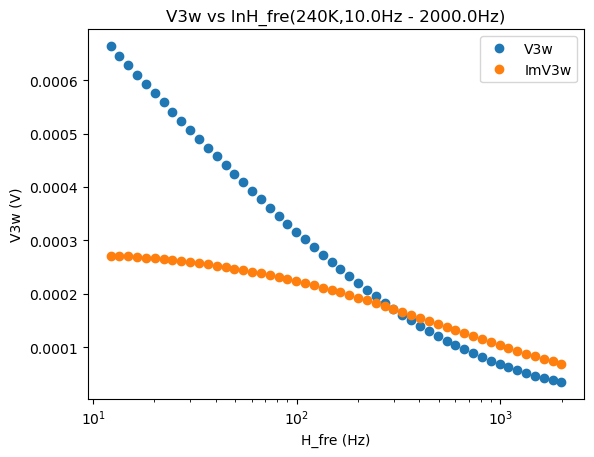

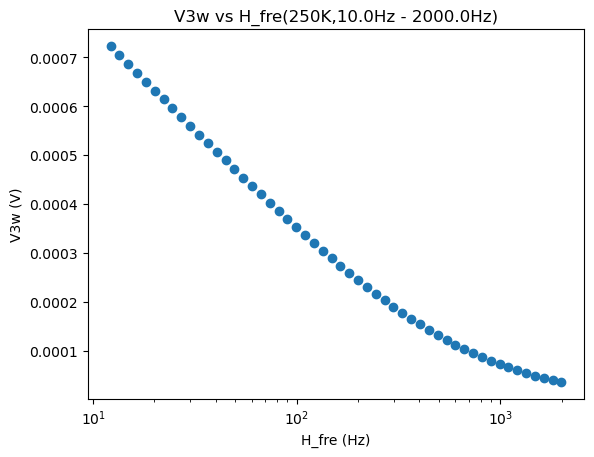

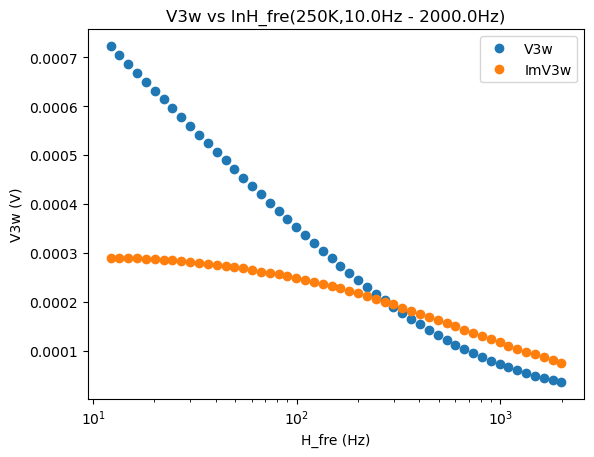

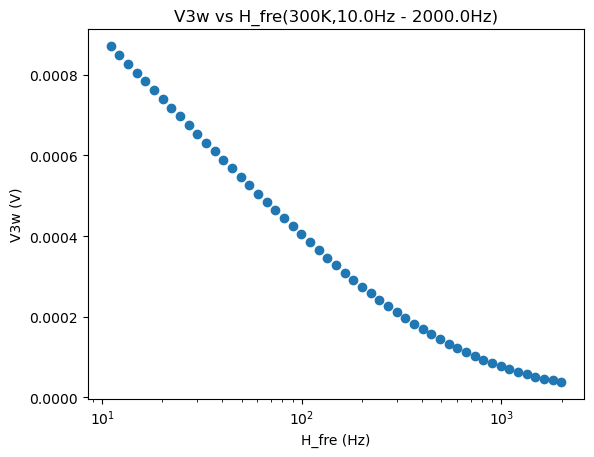

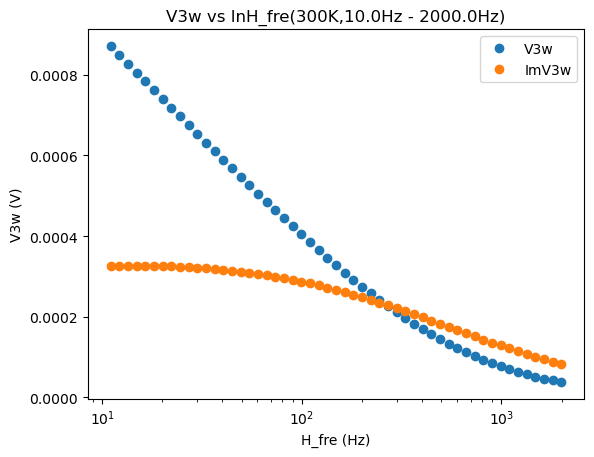

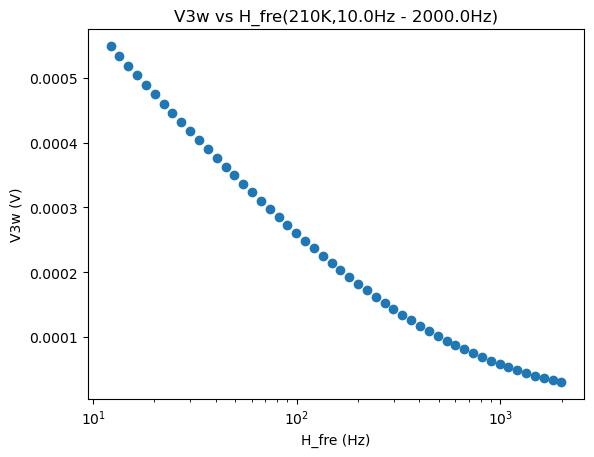

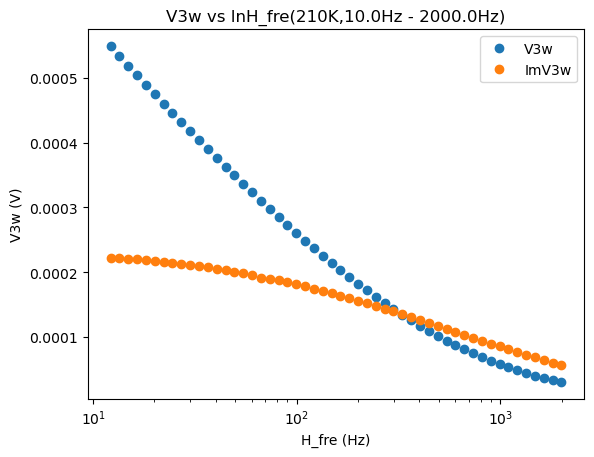

In [14]:
 #==================データの用いる数,範囲=======================
first_number=1
last_number=12
freq_min = 10.0
freq_max = 2000.0

now_str = datetime.datetime.now().strftime('%Y_%m%d_%H;%M;%S')
actual_min_freq = float('inf')
actual_max_freq = float('-inf')

for i in range(first_number, last_number+1):
    df_name = f'df_{i}'
    current_df = globals().get(df_name)
    if current_df is None:
        print(f"データフレーム '{df_name}' が見つかりませんでした。スキップします。")
        continue
    filtered_df = current_df[(current_df[' Current_Freq(Hz)'] >= freq_min) & (current_df[' Current_Freq(Hz)'] <= freq_max)]
    try:
        plt.figure()
        x = filtered_df[' Current_Freq(Hz)']
        y = np.abs(filtered_df['V3omega(V)'])
        ImV3w=np.abs(filtered_df[' ImV3omega(V)'])
        plt.plot(x, y, marker='o',  linestyle='None')
        plt.title(f'V3w vs H_fre({temp_map[df_name]}K,{freq_min}Hz - {freq_max}Hz)')
        plt.xlabel('H_fre (Hz)')
        plt.ylabel('V3w (V)')
        plt.xscale('log')
        plt.savefig(f'解析画像/測定データ(圧力媒体)/測定データ_実部_{file_names[df_name]}_{now_str}.svg', format='svg', bbox_inches='tight')
        plt.show()
        plt.plot(x, y, marker='o',  linestyle='None',label='V3w')
        plt.plot(x, ImV3w, marker='o',  linestyle='None',label='ImV3w')
        plt.title(f'V3w vs lnH_fre({temp_map[df_name]}K,{freq_min}Hz - {freq_max}Hz)')
        plt.xlabel('H_fre (Hz)')
        plt.ylabel('V3w (V)')       
        plt.xscale('log')
        plt.legend()
        plt.savefig(f'解析画像/測定データ(圧力媒体)/測定データ_実部,虚部_{file_names[df_name]}_{now_str}.svg', format='svg', bbox_inches='tight')
        plt.show()       
    except KeyError as e:
        print(f"エラー: {df_name} に列 {e} がありません。")
    except Exception as e:
        print(f"エラー: {df_name} で予期せぬエラーが発生しました: {e}")

ワイヤーの長さ 3.89900e-03m
ワイヤーの半径 2.50000e-06m
[Kappa(W/mK), Cp_FC77(J/cm3), Cp_Wire(J/cm3)]
DE最適解: [0.08806798 2.39428969 2.71407308]

=== 最終フィッティング結果 ===
Kappa (FC77) [W/mK]          :8.80682e-02 +/-2.13116e-04
Spec. Heat (FC77) [J/cm^3]   :2.39426e+00 +/-1.83018e-02
Spec. Heat (Wire) [J/cm^3]   :2.71418e+00 +/-1.60741e-02
8.80682e-02 +/-2.13116e-04 2.39426e+00 +/-1.83018e-02 2.71418e+00 +/-1.60741e-02


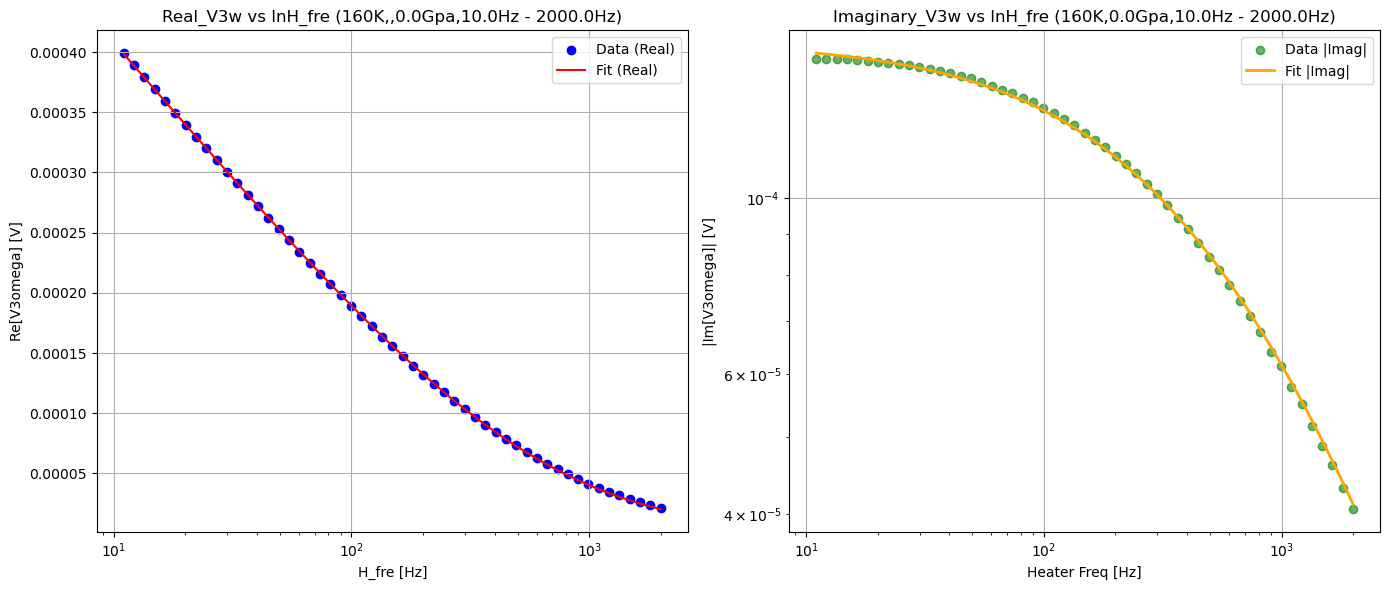

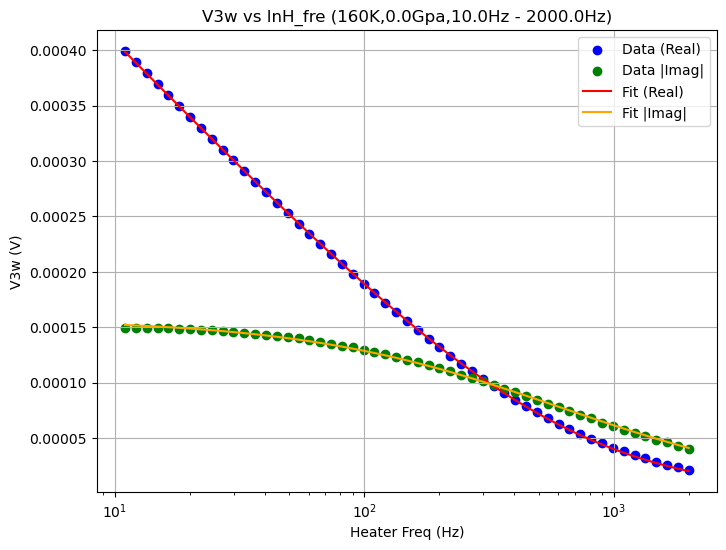

In [18]:
#=============解析データの特定=================
target_df_name = 'df_2'

a=(wire_diameter)/2*10**-6
l=(wire_length)*10**-3
print(f"ワイヤーの長さ {l:.5e}m")
print(f"ワイヤーの半径 {a:.5e}m")

now_str = datetime.datetime.now().strftime('%Y_%m%d_%H;%M;%S')

pi_a2=2*(np.pi)*a**2
pva_2=((average_Vw[target_df_name])**2)/((np.pi)*l*(average_res[target_df_name]))
V_2R=(average_Vw[target_df_name])/(2*(average_res[target_df_name]))
dR_dT= param[0]

def V3w_fitting_model_complex_abs_imag(freq, kappa, cp_fc77_scaled, cp_wire_scaled):
    specific_heat_FC77 = cp_fc77_scaled * 1e6
    specific_heat_wire = cp_wire_scaled * 1e6
    if kappa <= 1e-10 or specific_heat_FC77 <= 1e-10:
        return np.ones(len(freq)*2) * 1e10
    val_f = np.sqrt((freq * pi_a2 * specific_heat_FC77) / kappa ) * (1 + 1j)
    val_kv0 = kv(0, val_f)
    val_kv1 = kv(1, val_f)
    denominator = 2 * (val_kv1 / val_kv0) * kappa * val_f + 1j * 2 * pi_a2 * specific_heat_wire * (freq)
    V3w_complex = pva_2 * V_2R * dR_dT / denominator
    return np.hstack([np.real(V3w_complex), np.abs(np.imag(V3w_complex))])
scale_factor = 1e5  
def scaled_fitting_model(freq, kappa, cp_fc77_scaled, cp_wire_scaled):
    return V3w_fitting_model_complex_abs_imag(freq, kappa, cp_fc77_scaled, cp_wire_scaled) * scale_factor
def cost_function(params, x, y_data):
    kappa, cp_fc, cp_w = params
    y_model = V3w_fitting_model_complex_abs_imag(x, kappa, cp_fc, cp_w)
    residuals = y_data - y_model
    return np.sum(residuals**2) 
current_df = globals()[target_df_name].copy()

filtered_df = current_df[(current_df[' Current_Freq(Hz)'] >= freq_min) & (current_df[' Current_Freq(Hz)'] <= freq_max)]
x_data = filtered_df[' Current_Freq(Hz)'].values
y_data_real = np.abs(filtered_df['V3omega(V)']).values
y_data_imag = np.abs(filtered_df[' ImV3omega(V)']).values
y_data_complex = y_data_real + (1j * y_data_imag)
mask = ~np.isnan(x_data) & ~np.isnan(y_data_complex)
x_data = x_data[mask]
y_data_complex = y_data_complex[mask]
y_data_stacked = np.hstack([np.real(y_data_complex), np.abs(np.imag(y_data_complex))])
y_data_scaled = y_data_stacked * scale_factor
bounds = [
    (0.01, 0.2),   # Kappa
    (0.2, 5.3),   # Cp FC77
    (0.2, 5.3)    # Cp Wire
]
# [Kappa(W/mK), Cp_FC77(J/cm3), Cp_Wire(J/cm3)]
try:
    result_de = differential_evolution(
        cost_function,
        bounds,
        args=(x_data, y_data_stacked), 
        strategy='best1bin',
        maxiter=1000,
        popsize=15,
        tol=1e-5,
        mutation=(0.5, 1),
        recombination=0.7,
        seed=42 
    )
    
    best_params_de = result_de.x
    print(f"[Kappa(W/mK), Cp_FC77(J/cm3), Cp_Wire(J/cm3)]")
    print(f"DE最適解: {best_params_de}")
    popt, pcov = curve_fit(
        scaled_fitting_model,  
        x_data, 
        y_data_scaled,         
        p0=best_params_de,      
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
        ftol=1e-12,
        xtol=1e-12
    )
    k_est, cp_fc77_est, cp_wire_est = popt
    perr = np.sqrt(np.diag(pcov))
    k_err, cp_fc77_err, cp_wire_err = perr
    
    print("\n=== 最終フィッティング結果 ===")
    print(f"Kappa (FC77) [W/mK]          :{k_est:.5e} +/-{k_err:.5e}")
    print(f"Spec. Heat (FC77) [J/cm^3]   :{cp_fc77_est:.5e} +/-{cp_fc77_err:.5e}")
    print(f"Spec. Heat (Wire) [J/cm^3]   :{cp_wire_est:.5e} +/-{cp_wire_err:.5e}")
    
    print(f"{k_est:.5e} +/-{k_err:.5e} {cp_fc77_est:.5e} +/-{cp_fc77_err:.5e} {cp_wire_est:.5e} +/-{cp_wire_err:.5e}")
    y_fit_stacked = V3w_fitting_model_complex_abs_imag(x_data, k_est, cp_fc77_est, cp_wire_est)
    y_fit_real = y_fit_stacked[:len(x_data)] 
    y_fit_imag_abs = y_fit_stacked[len(x_data):] 
    real_name = file_names[target_df_name]
    try:
        title_temp = temp_map[target_df_name]
    except:
        title_temp = "Unknown Temp"
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(x_data, np.real(y_data_complex), label='Data (Real)', color='blue')
    axes[0].plot(x_data, y_fit_real, label='Fit (Real)', color='red')
    axes[0].set_title(f'Real_V3w vs lnH_fre ({title_temp}K,,{press}Gpa,{freq_min}Hz - {freq_max}Hz)')
    axes[0].set_xlabel('H_fre [Hz]')
    axes[0].set_xscale('log')
    axes[0].set_ylabel('Re[V3omega] [V]')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].scatter(x_data, np.abs(np.imag(y_data_complex)), label='Data |Imag|', color='green', alpha=0.6)
    axes[1].plot(x_data, y_fit_imag_abs, label='Fit |Imag|', color='orange', linewidth=2)
    axes[1].set_title(f'Imaginary_V3w vs lnH_fre ({title_temp}K,{press}Gpa,{freq_min}Hz - {freq_max}Hz)')
    axes[1].set_xlabel('Heater Freq [Hz]')
    axes[1].set_xscale('log')
    axes[1].set_yscale('log') # 両対数にする
    axes[1].set_ylabel('|Im[V3omega]| [V]')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'解析画像/fitting(圧力媒体)/fittingデータ実部,虚部_{real_name}_{now_str}.svg', format='svg', bbox_inches='tight')
    plt.show()
    
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, np.real(y_data_complex), label='Data (Real)', color='blue')
    plt.scatter(x_data, np.abs(np.imag(y_data_complex)), label='Data |Imag|', color='green')
    plt.plot(x_data, y_fit_real, label='Fit (Real)', color='red')
    plt.plot(x_data, y_fit_imag_abs, label='Fit |Imag|', color='orange')
    plt.legend()
    plt.title(f'V3w vs lnH_fre ({title_temp}K,{press}Gpa,{freq_min}Hz - {freq_max}Hz)')
    plt.xlabel('Heater Freq (Hz)')
    plt.ylabel('V3w (V)')        
    plt.xscale('log')
    plt.grid(True)
    plt.savefig(f'解析画像/fitting(圧力媒体)/fittingデータ_{real_name}_{now_str}.svg', format='svg', bbox_inches='tight')
    plt.show()

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"フィッティングエラー: {e}")

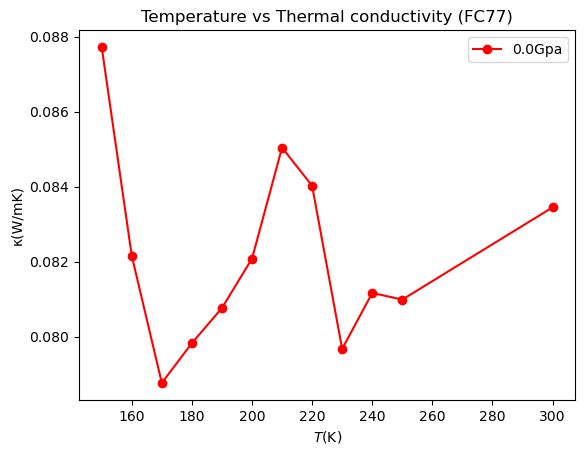

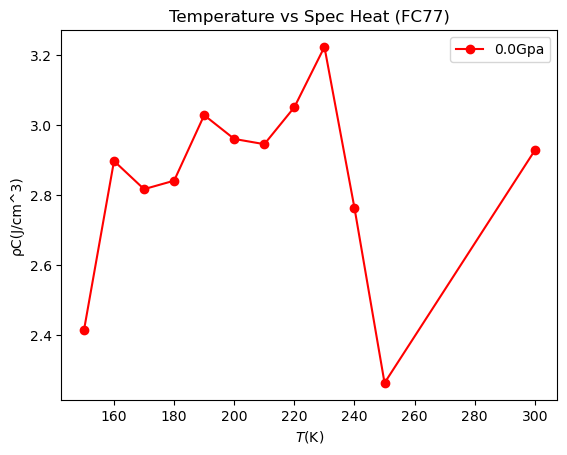

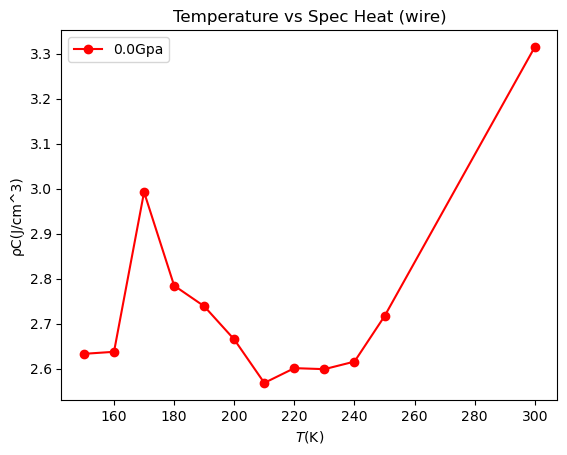

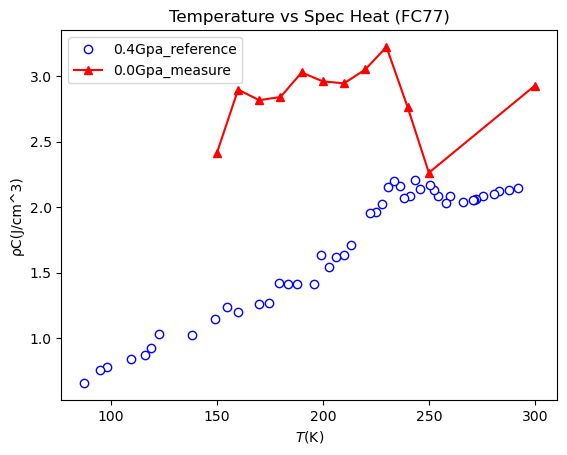

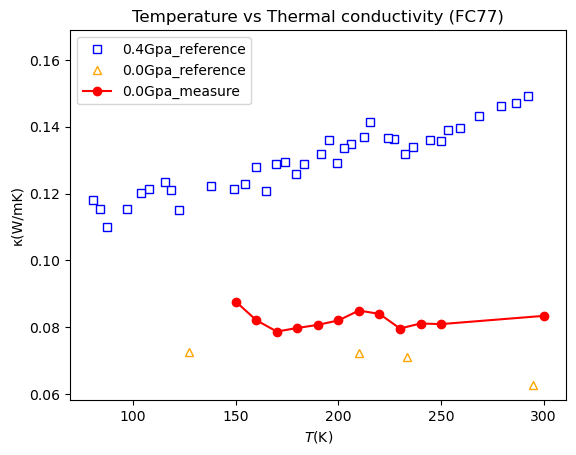

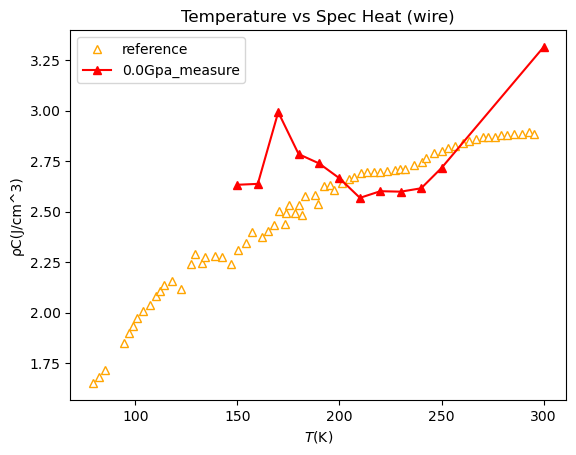

In [19]:
df = pd.read_excel('圧力媒体_熱伝導率.xlsx', sheet_name='fre30~1500,0.0Gpa,5um,条件下')
x_temp_0_measure = df['温度(0.0Gpa)[K]'].values
y_kappa_0_measure= df['Kappa (FC77,0.0Gpa) [W/mK]'].values     
y_pc_FC77_0_measure = df['Spec. Heat (FC77,0.0Gpa) [J/cm^3]'].values
y_pc_wire_0_measure = df['Spec. Heat (Wire,0.0Gpa) [J/cm^3]'].values

df = pd.read_excel('文献値.xlsx')
x_tempkappa_0_reference = df['温度(0.0Gpa,文献値)[K]'].values
y_kappa_0_reference= df['Kappa (FC77,0.0Gpa,文献値) [W/mK]'].values

x_tempkappa_4_reference = df['温度(Kappa,0.4Gpa,文献値)[K]'].values
y_kappa_4_reference= df['Kappa (FC77,0.4Gpa,文献値) [W/mK]'].values
x_temppc_4_reference = df['温度(FC77pc,0.4Gpa,文献値)[K]'].values
y_pc_FC77_4_reference = df['Spec. Heat (FC77,0.4Gpa,文献値) [J/cm^3]'].values
x_temp_pt_reference = df['温度(pc,pt,文献値)[K]'].values
y_pc_pt_reference = df['Spec. Heat (pt,文献値) [J/cm^3]'].values

plt.plot(x_temp_0_measure, y_kappa_0_measure, marker='o', linestyle='-', label='0.0Gpa', color='red')
plt.xlabel("$T$(K)")   
plt.ylabel('κ(W/mK)')  
plt.title('Temperature vs Thermal conductivity (FC77)') 
plt.legend()
plt.show()

plt.plot(x_temp_0_measure, y_pc_FC77_0_measure, marker='o', linestyle='-', label='0.0Gpa', color='red')
plt.xlabel("$T$(K)")   
plt.ylabel('ρC(J/cm^3)')  
plt.title('Temperature vs Spec Heat (FC77)') 
plt.legend()
plt.show()

plt.plot(x_temp_0_measure, y_pc_wire_0_measure, marker='o', linestyle='-', label='0.0Gpa', color='red')
plt.xlabel("$T$(K)")   
plt.ylabel('ρC(J/cm^3)')  
plt.title('Temperature vs Spec Heat (wire)') 
plt.legend()
plt.show()

plt.plot(x_temppc_4_reference, y_pc_FC77_4_reference, marker='o', linestyle='None',label='0.4Gpa_reference', color='white',markeredgecolor="blue", markeredgewidth= 1)
plt.plot(x_temp_0_measure, y_pc_FC77_0_measure, marker='^', linestyle='-',label='0.0Gpa_measure', color='red')
plt.xlabel("$T$(K)")   
plt.ylabel('ρC(J/cm^3)')  
plt.title('Temperature vs Spec Heat (FC77)') 
plt.legend(loc='upper left')
plt.show()

plt.plot(x_tempkappa_4_reference, y_kappa_4_reference, marker='s', linestyle='None',label='0.4Gpa_reference', color='white',markeredgecolor="blue", markeredgewidth= 1)
plt.plot(x_tempkappa_0_reference,y_kappa_0_reference, marker='^', linestyle='None',label='0.0Gpa_reference', color='white',markeredgecolor="orange", markeredgewidth= 1)
plt.plot(x_temp_0_measure, y_kappa_0_measure, marker='o', linestyle='-',label='0.0Gpa_measure', color='red')
plt.ylabel("κ(W/mK)")  
bottom, top = plt.ylim() 
plt.ylim(bottom, top * 1.1)
plt.xlabel("$T$(K)")   
plt.title('Temperature vs Thermal conductivity (FC77)') 
plt.legend(loc='upper left')
plt.show()

plt.plot(x_temp_pt_reference, y_pc_pt_reference, marker='^', linestyle='None', label='reference',color='white',markeredgecolor="orange", markeredgewidth= 1)
plt.plot(x_temp_0_measure, y_pc_wire_0_measure, marker='^', linestyle='-', label='0.0Gpa_measure', color='red')
plt.xlabel("$T$(K)")  
plt.ylabel('ρC(J/cm^3)')  
plt.title('Temperature vs Spec Heat (wire)') 
plt.legend(loc='upper left')
plt.show()

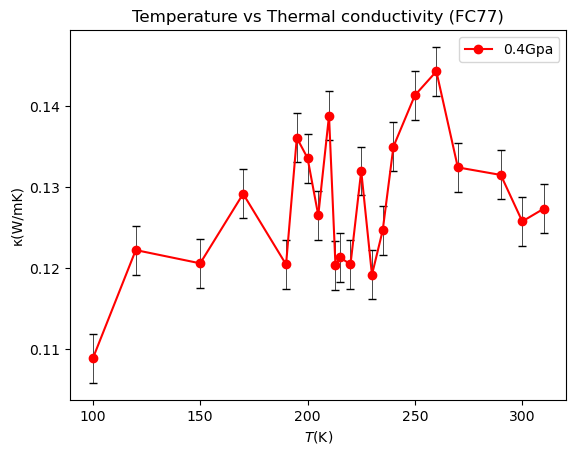

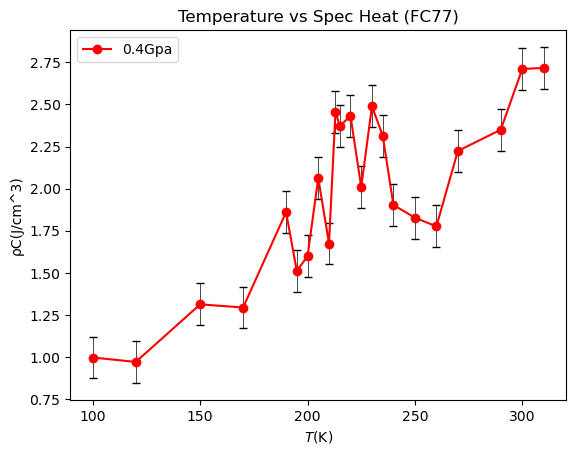

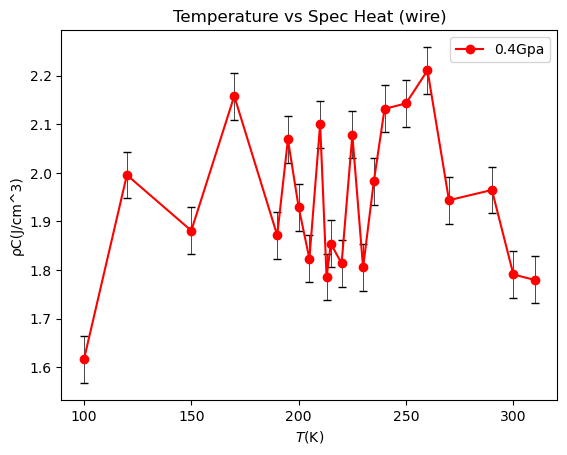

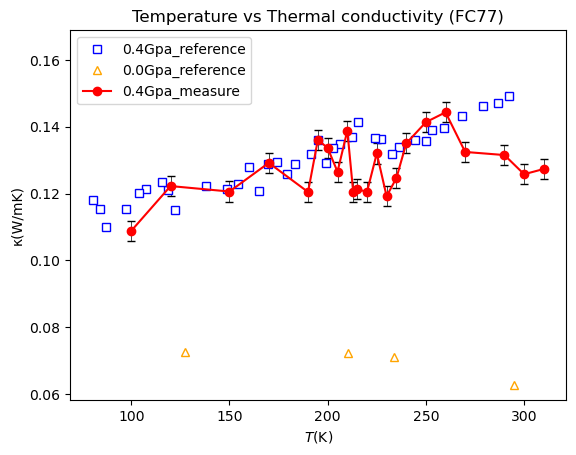

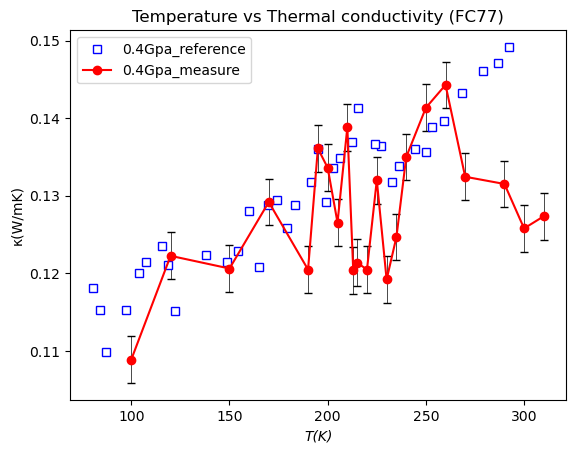

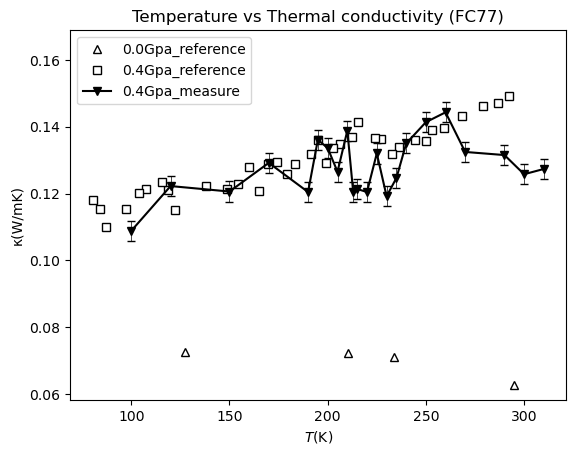

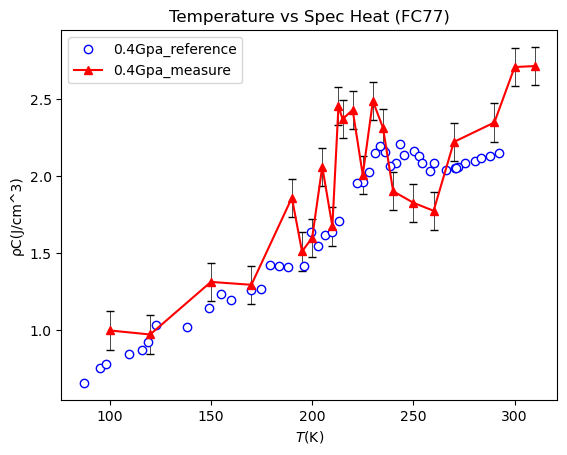

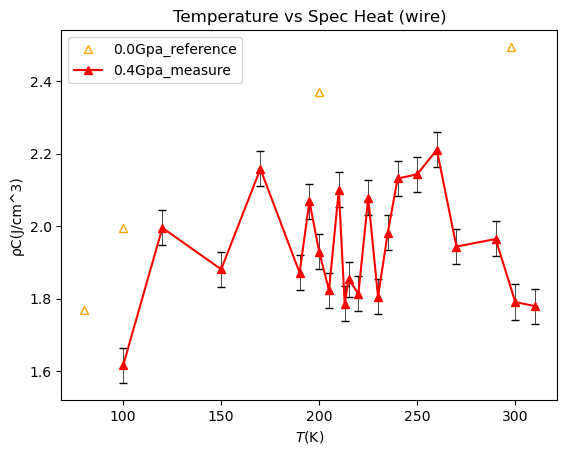

In [20]:
df = pd.read_excel('FC77 3w法.xlsx', sheet_name='解析(30-1500Hz,0.4Gpa,初期値自動,重みなし)')

def extract_mean(series):
    return series.astype(str).str.extract(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)')[0].astype(float).values
x_temp_1_measure = df['温度(0.1Gpa)'].values
y_kappa_1_measure= extract_mean(df['熱伝導率(0.1Gpa)'])           
y_pc_FC77_1_measure = extract_mean(df['体積比熱(FC77,0.1Gpa)'])  
y_pc_wire_1_measure = extract_mean(df['体積比熱(ワイヤー,0.1Gpa)']) 

x_temp_4_measure = df['温度(0.4Gpa)'].values
y_kappa_4_measure= extract_mean(df['熱伝導率(0.4Gpa)'])           
y_pc_FC77_4_measure = extract_mean(df['体積比熱(FC77,0.4Gpa)'])  
y_pc_wire_4_measure = extract_mean(df['体積比熱(ワイヤー,0.4Gpa)']) 

x_temp_0 = extract_mean(df['温度0.0Gpa'])
y_kappa_0 = extract_mean(df['熱伝導率0.0Gpa'])
x_temp_4 = extract_mean(df['温度熱伝導率0.4Gpa'])
y_kappa_4 = extract_mean(df['熱伝導率0.4Gpa'])
x_temp_4_pc = extract_mean(df['温度体積比熱0.4Gpa'])
y_4_pc = extract_mean(df['体積比熱0.4Gpa'])
Au_temp_0 = extract_mean(df['金の文献値温度[K]'])
Au_0_pc = extract_mean(df['金の文献値体積比熱[J/cm3K]'])

yerr_kappa_4=extract_mean(df['標準偏差[熱伝導率]'])
yerr_pC_FC77_4=extract_mean(df['標準偏差[体積比熱FC77]'])
yerr_pC_wire_4=extract_mean(df['標準偏差[体積比熱ワイヤー]'])

marker_style = {'markeredgecolor': 'black', 'markeredgewidth': 1}

plt.errorbar(x_temp_4_measure,y_kappa_4_measure, yerr_kappa_4,capsize=3, linestyle='None', markersize=10, ecolor="black", elinewidth=0.5)
plt.plot(x_temp_4_measure, y_kappa_4_measure, marker='o', linestyle='-', label='0.4Gpa', color='red')
plt.xlabel("$T$(K)")   
plt.ylabel('κ(W/mK)')  
plt.title('Temperature vs Thermal conductivity (FC77)') 
plt.legend()
plt.show()

plt.errorbar(x_temp_4_measure,y_pc_FC77_4_measure, yerr_pC_FC77_4,capsize=3, linestyle='None', markersize=10, ecolor="black", elinewidth=0.5)
plt.plot(x_temp_4_measure, y_pc_FC77_4_measure, marker='o', linestyle='-', label='0.4Gpa', color='red')
plt.xlabel("$T$(K)")   
plt.ylabel('ρC(J/cm^3)')  
plt.title('Temperature vs Spec Heat (FC77)') 
plt.legend()
plt.show()

plt.errorbar(x_temp_4_measure,y_pc_wire_4_measure, yerr_pC_wire_4,capsize=3, linestyle='None', markersize=10, ecolor="black", elinewidth=0.5)
plt.plot(x_temp_4_measure, y_pc_wire_4_measure, marker='o', linestyle='-', label='0.4Gpa', color='red')
plt.xlabel("$T$(K)")   
plt.ylabel('ρC(J/cm^3)')  
plt.title('Temperature vs Spec Heat (wire)') 
plt.legend()
plt.show()

plt.errorbar(x_temp_4_measure,y_kappa_4_measure, yerr_kappa_4, capsize=3, linestyle='None', markersize=10, ecolor="black", elinewidth=0.5)
plt.plot(x_temp_4, y_kappa_4, marker='s', linestyle='None',label='0.4Gpa_reference', color='white',markeredgecolor="blue", markeredgewidth= 1)
plt.plot(x_temp_0, y_kappa_0, marker='^', linestyle='None',label='0.0Gpa_reference', color='white',markeredgecolor="orange", markeredgewidth= 1)
plt.plot(x_temp_4_measure, y_kappa_4_measure, marker='o', linestyle='-',label='0.4Gpa_measure', color='red')

plt.ylabel("κ(W/mK)")  
bottom, top = plt.ylim() 
plt.ylim(bottom, top * 1.1)
plt.xlabel("$T$(K)")   
plt.title('Temperature vs Thermal conductivity (FC77)') 
plt.legend(loc='upper left')
plt.show()



plt.errorbar(x_temp_4_measure,y_kappa_4_measure, yerr_kappa_4, capsize=3, linestyle='None', markersize=10, ecolor="black", elinewidth=0.5)
plt.plot(x_temp_4, y_kappa_4, marker='s', linestyle='None',label='0.4Gpa_reference', color='white',markeredgecolor="blue", markeredgewidth= 1)
plt.plot(x_temp_4_measure, y_kappa_4_measure, marker='o', linestyle='-',label='0.4Gpa_measure', color='red')
plt.ylabel("κ(W/mK)")  
plt.xlabel("T(K)",fontstyle="italic")  
plt.title('Temperature vs Thermal conductivity (FC77)') 
plt.legend(loc='upper left')
plt.show()


plt.errorbar(x_temp_4_measure,y_kappa_4_measure, yerr_kappa_4, capsize=3, linestyle='None', markersize=10, ecolor="black", elinewidth=0.5)
plt.plot(x_temp_0, y_kappa_0, marker='^', linestyle='None',label='0.0Gpa_reference', color='white',**marker_style)
plt.plot(x_temp_4, y_kappa_4, marker='s', linestyle='None',label='0.4Gpa_reference', color='white',**marker_style)
plt.plot(x_temp_4_measure, y_kappa_4_measure, marker='v', linestyle='-',label='0.4Gpa_measure', color='black',**marker_style)
plt.ylabel("κ(W/mK)")  
plt.xlabel("$T$(K)")  
bottom, top = plt.ylim() 
plt.ylim(bottom, top * 1.1)
plt.title('Temperature vs Thermal conductivity (FC77)') 
plt.legend(loc='upper left')
plt.show()


plt.errorbar(x_temp_4_measure,y_pc_FC77_4_measure, yerr_pC_FC77_4,capsize=3, linestyle='None', markersize=10, ecolor="black", elinewidth=0.5)
plt.plot(x_temp_4_pc, y_4_pc, marker='o', linestyle='None',label='0.4Gpa_reference', color='white',markeredgecolor="blue", markeredgewidth= 1)
plt.plot(x_temp_4_measure, y_pc_FC77_4_measure, marker='^', linestyle='-',label='0.4Gpa_measure', color='red')
plt.xlabel("$T$(K)")   
plt.ylabel('ρC(J/cm^3)')  
plt.title('Temperature vs Spec Heat (FC77)') 
plt.legend(loc='upper left')
plt.show()


plt.errorbar(x_temp_4_measure,y_pc_wire_4_measure, yerr_pC_wire_4,capsize=3, linestyle='None', markersize=10, ecolor="black", elinewidth=0.5)
plt.plot(Au_temp_0, Au_0_pc, marker='^', linestyle='None', label='0.0Gpa_reference',color='white',markeredgecolor="orange", markeredgewidth= 1)
plt.plot(x_temp_4_measure, y_pc_wire_4_measure, marker='^', linestyle='-', label='0.4Gpa_measure', color='red')
plt.xlabel("$T$(K)")  
plt.ylabel('ρC(J/cm^3)')  
plt.title('Temperature vs Spec Heat (wire)') 
plt.legend(loc='upper left')
plt.show()